In [1]:
from google.colab import drive
drive.mount('/content/drive')

%cd drive/MyDrive/MaliciousCallDetection/

!cp /content/drive/MyDrive/MaliciousCallDetection/spectrograms_backup.zip /content
!unzip /content/spectrograms_backup.zip -d /content
!mv /content/content/spectrograms/ /content
!rm -r /content/content
!git config --global user.email "marinescudragos2014@gmail.com"
!git config --global user.name "Marinescu Dragos"


Mounted at /content/drive
/content/drive/MyDrive/MaliciousCallDetection


In [ ]:
!pip install -r /content/drive/MyDrive/MaliciousCallDetection/requirements.txt

In [ ]:
from tqdm import tqdm
from typing import Optional
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import wandb
from torch.utils.data import Dataset, DataLoader, random_split
import torch.nn as nn
import torch.optim as optim
import os
import librosa
from IPython.display import Audio
import random
import wandb
from collections import Counter
from pathlib import Path
wandb.login()

In [ ]:

def save_spectrograms(base_path, output_path, sr=16000, window_size=5.0, min_overlap=1.5):
    window_size_samples = int(window_size * sr)
    min_overlap_samples = int(min_overlap * sr)

    # for category in ['testing','training']:
    #     os.makedirs(os.path.join(output_path, category), exist_ok=True)

    print(f"Processing data from '{base_path}'...")
    label=0
    for category in ['validation','training']:
      dir_path = os.path.join(base_path, category)
      if not os.path.exists(dir_path):
        continue

      valid_files = [f for f in os.listdir(dir_path) if f.lower().endswith(('.wav', '.mp3'))]
      print(len(valid_files))
      print(f"\nProcessing category: {category.upper()} ({len(valid_files)} files)")
      for f in tqdm(valid_files, desc=f"{category} progress", unit="file"):
          path = os.path.join(dir_path, f)

          try:
              audio_full, _ = librosa.load(path, sr=sr)
              total_samples = len(audio_full)
          except Exception as e:
              print(f"Error loading {f}: {e}. Skipping file.")
              continue

          if total_samples < int(8.5 * sr) and total_samples >= window_size_samples:
              step = max(1, total_samples - window_size_samples)
          else:
              step = window_size_samples - min_overlap_samples

          window_idx = 0
          for start in range(0, total_samples, step):
              save_file_name = f"{os.path.splitext(f)[0]}_spectogram_{window_idx}.pt"
              save_path = os.path.join(output_path, "normal", save_file_name)

              if os.path.exists(save_path):
                  window_idx += 1
                  continue

              audio_segment = audio_full[start : min(total_samples,start + window_size_samples)]

              if len(audio_segment) < window_size_samples:
                pad_length = window_size_samples - len(audio_segment)
                audio_segment = np.pad(audio_segment, (0, pad_length), mode="constant")

              if is_silent(audio_segment, sr): #skip window
                  window_idx += 1
                  continue

              audio_segment=simulate_telephone(audio_segment,sr=sr,prob=0.5)

              mel_spec = librosa.feature.melspectrogram(y=audio_segment, sr=sr, n_fft=2048,hop_length=512, n_mels=128) #shape=(128,157)
              log_mel = librosa.power_to_db(mel_spec, ref=np.max) #sets the basolute loudest pixel to be 0 and everithing else negative
              log_mel = np.clip(log_mel, -80, 0) #avoid outliers -80 dB = absolute silence
              log_mel = (log_mel - np.mean(log_mel)) / (np.std(log_mel) + 1e-9)
              tensor_mel = torch.tensor(log_mel, dtype=torch.float32).unsqueeze(0) #unsqueeze(0) adds an extra layer at pos 0

              try:
                  torch.save(tensor_mel, save_path)
              except Exception as e:
                  print(f"Error saving spectrogram {save_file_name} from {f}: {e}. Skipping segment.")
              window_idx += 1

    print(f"\nDone! Every spectogram is in '{output_path}'.")

#save_spectrograms("/content/drive/MyDrive/MaliciousCallDetection/dataset/Audio_With_Noise","/content/spectrograms")

In [ ]:
%cd /content/spectrograms/malicious
!ls -1 | wc -l
%cd /content/spectrograms/normal
!ls -1 | wc -l
#46139 malicious
#66966 normal

/content/spectrograms/malicious
46139
/content/spectrograms/normal
66966


In [ ]:


folder = Path("/content/drive/MyDrive/MaliciousCallDetection/dataset/normal")

extensions = Counter(
    p.suffix.lower() or "<no extension>"
    for p in folder.iterdir()
    if p.is_file()
)

extensions

Counter({'.wav': 1648, '.mp3': 40})

In [ ]:
#Cleanup

def cleanup():

  base_dir = "/content/drive/MyDrive/MaliciousCallDetection/dataset/spectrograms"
  categories = ["normal", "malicious"]

  corrupt_count = 0
  blank_count = 0

  print("Starting deep clean of spectrograms...")

  for category in categories:
      dir_path = os.path.join(base_dir, category)
      if not os.path.exists(dir_path):
          continue

      files = [f for f in os.listdir(dir_path) if f.endswith('.pt')]

      for f in tqdm(files, desc=f"Cleaning {category}"):
          path = os.path.join(dir_path, f)

          try:
              mel = torch.load(path)
          except Exception as e:
              os.remove(path)
              corrupt_count += 1
              continue  #
          if mel.min().item() == mel.max().item():
              os.remove(path)
              blank_count += 1

  print("\nCleanup Complete!")
  print(f"Successfully deleted {corrupt_count} corrupted files.") #1 corrupted file deleted
  print(f"Successfully deleted {blank_count} blank/silent files.") #83 blank files deleted
#cleanup()


In [ ]:
from numbers import Number
import random
import re
def spectrograms_random_splits(spectogram_path,train_ratio=0.8,val_ratio=0.1):

  normal_sources={}
  malicious_sources={}

  for label, category in enumerate(['normal', 'malicious']):
    dir_path = os.path.join(spectogram_path, category)
    if not os.path.exists(dir_path): continue

    for f in os.listdir(dir_path):
      if f.endswith('.pt'):
        prefix = f.split('_spectogram_')[0]
        pattern = r"(.*\[[^\]]+\])" #for yt videos
        match = re.search(pattern, prefix)#

        if match:
          source_name = f"{category}_{match.group(1)}"
        else:
          source_name=f"{category}_{prefix}"


        full_path=os.path.join(dir_path,f)

        target_dict=normal_sources if label==0 else malicious_sources

        if source_name not in target_dict: #key=audio name, value= dictionary(samples=list of spectrograms, label)
          target_dict[source_name]={'spectrograms': [], 'label': label}

        target_dict[source_name]['spectrograms'].append(full_path)

  def get_split_lists(source_dict):
      source_ids = list(source_dict.keys()) #list of audios
      random.seed(1)
      random.shuffle(source_ids)
      n = len(source_ids)
      train_end = int(n * train_ratio)
      val_end = int(n * (train_ratio + val_ratio))
      train_ids = source_ids[:train_end]
      val_ids = source_ids[train_end:val_end]
      test_ids = source_ids[val_end:]

      return train_ids, val_ids, test_ids

  norm_train, norm_val, norm_test = get_split_lists(normal_sources)
  mal_train, mal_val, mal_test = get_split_lists(malicious_sources)

  def flatten_to_list(audio_list,source_dict):
    spectrogram_list=[]

    for audio_file in audio_list:
      label=source_dict[audio_file]['label']
      for spectrogram in source_dict[audio_file]['spectrograms']:
        spectrogram_list.append((spectrogram,label))
    return spectrogram_list

  train = flatten_to_list(norm_train, normal_sources) + flatten_to_list(mal_train, malicious_sources)
  val   = flatten_to_list(norm_val, normal_sources)   + flatten_to_list(mal_val, malicious_sources)
  test  = flatten_to_list(norm_test, normal_sources)  + flatten_to_list(mal_test, malicious_sources)

  random.shuffle(train)
  random.shuffle(val)
  random.shuffle(test)
  return train, val, test


113104


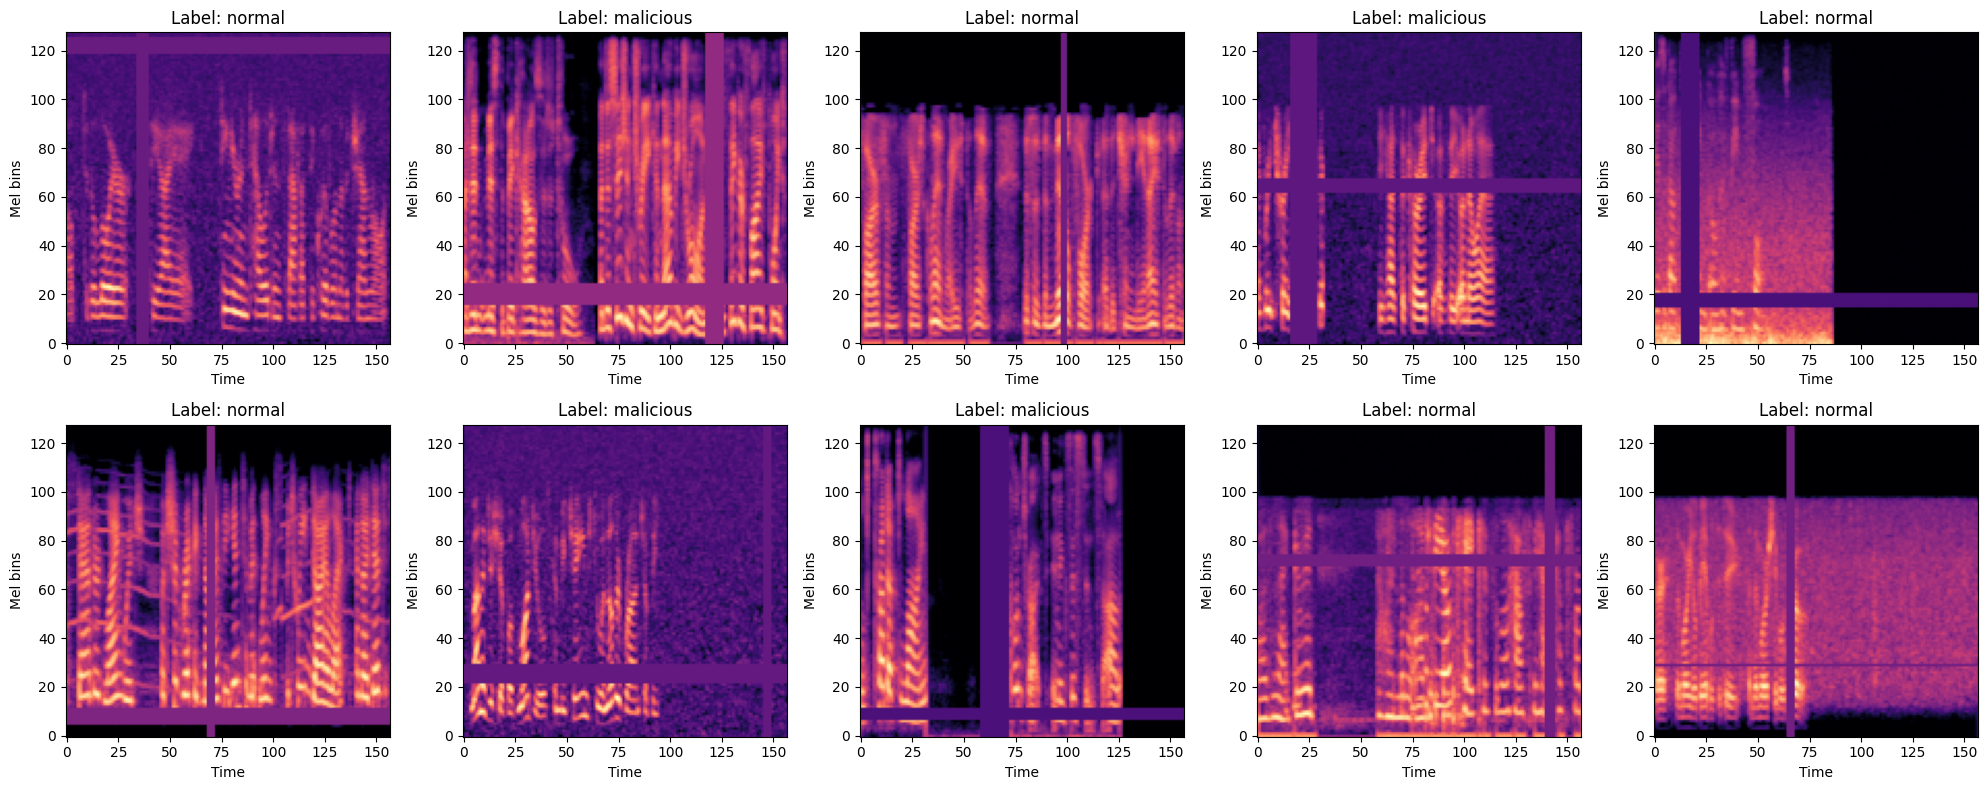

In [ ]:
import random
import torchaudio.transforms as T
class Spectrogram(Dataset):
  def __init__(self,file_list,augment=False):
    self.samples=file_list
    self.augment = augment
    self.time_mask = T.TimeMasking(time_mask_param=20) #vertical black line
    self.freq_mask = T.FrequencyMasking(freq_mask_param=10) # horizontal

  def __len__(self):
    return len(self.samples)

  def __getitem__(self, idx):
    path,label=self.samples[idx]
    mel_tensor=torch.load(path)

    if self.augment:
      # SpecAugment: randomly mask time and frequency bands
      mel_tensor = self.time_mask(mel_tensor)
      mel_tensor = self.freq_mask(mel_tensor)
      # Add small Gaussian noise
      if torch.rand(1).item() > 0.5:
        mel_tensor = mel_tensor + 0.01 * torch.randn_like(mel_tensor) #torch.randn_like generate random numbers distribution with mean=0, and std=1
        #the result has 0.01 std dev
    return mel_tensor,label,path

train,val,test=spectrograms_random_splits("/content/spectrograms")
specs = train + test + val
p=Spectrogram(specs,augment=True) #just to check
print(len(p))


fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

random_spectrograms=np.random.choice(len(p), size=10, replace=False)
for idx,spectogram_idx in enumerate(random_spectrograms):
    mel, label,_ = p[spectogram_idx]          # mel: (1, 128, 157)
    mel = mel.squeeze(0)       # (128, 157)

    axes[idx].imshow(
        mel,
        origin='lower',
        aspect='auto',
        cmap='magma'
    )

    axes[idx].set_title(f"Label: {'malicious' if label==1 else 'normal'}")
    axes[idx].set_xlabel("Time")
    axes[idx].set_ylabel("Mel bins")

plt.tight_layout()
plt.show()

In [ ]:
# from torch.nn.modules.dropout import Dropout

# def configure_optimizer(model: nn.Module,lr=0.001) -> optim.Optimizer:
#     return optim.Adam(model.parameters(), lr)

# class CNN(nn.Module):
#     def __init__(self,dropout=0.41):
#         super(CNN, self).__init__()
#         self.features = nn.Sequential(
#             #we use padding because we don't want to loose pixels from the images margins, now the output matrix is exactly as the input
#             #when working with spectrograms this is important
#             #formula : out=(W−K+2P)/S ​+ 1
#             nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1),#in_channels=1 because spectogram is grayscale not RGB
#             nn.BatchNorm2d(32), #Normalization(mean=0,std=1)
#             nn.ReLU(),
#             nn.MaxPool2d(2),#reduce image in half, concentrating on the most imp pixel

#             nn.Conv2d(32, 64, kernel_size=3, padding=1),
#             nn.BatchNorm2d(64),
#             nn.ReLU(),
#             nn.MaxPool2d(2),

#             nn.Conv2d(64, 128, kernel_size=3, padding=1),
#             nn.BatchNorm2d(128),
#             nn.ReLU(),
#             nn.MaxPool2d(2),

#             nn.Conv2d(128, 256, kernel_size=3, padding=1),
#             nn.BatchNorm2d(256),
#             nn.ReLU(),
#             nn.MaxPool2d(2)
#         )

#         # This forces the spatial dimensions down to 1x1, regardless of input length.
#         self.pool = nn.AdaptiveAvgPool2d((1, 1)) #256 channels, 1 height, 1 width

#         # Classification
#         self.classifier = nn.Sequential(
#             nn.Flatten(),
#             nn.Linear(256, 256), # It's 256 because the last Conv2d output 256 channels
#             nn.ReLU(),
#             nn.Dropout(dropout), # Added dropout to prevent overfitting
#             nn.Linear(256, 2) # 2=num_classes
#         )

#     def forward(self, x):
#         x = self.features(x)
#         x = self.pool(x)
#         x = self.classifier(x)
#         return x


In [ ]:
from torch.nn.modules.dropout import Dropout

def configure_optimizer(model: nn.Module,lr=0.001,weight_decay=0.000222) -> optim.Optimizer:
    return optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

class CNN(nn.Module):
    def __init__(self,conv_dropout=0.118,dropout=0.573): #adauga conv_drop iar apoi conv_dropout*1.5 si conv_dropout*2
        super(CNN, self).__init__()
        self.features = nn.Sequential(
            #we use padding because we don't want to loose pixels from the images margins, now the output matrix is exactly as the input
            #when working with spectrograms this is important
            #formula : out=(W−K+2P)/S ​+ 1 (128-3+2)/1 +1
            #params: out_channels * (in_channels * kernel_H * kernel_W + 1)
            nn.Conv2d(in_channels=1, out_channels=64, kernel_size=3, padding=1),#in_channels=1 because spectogram is grayscale not RGB
            nn.BatchNorm2d(64), #Normalization(mean=0,std=1), control the values so relu doesn't kill a lot of neurons, normalization is done on every channel
            nn.ReLU(),
            nn.Conv2d(64,64,kernel_size=3,padding=1),
            nn.BatchNorm2d(64), #Normalization(mean=0,std=1)
            nn.ReLU(),
            nn.MaxPool2d(2),#reduce image in half, concentrating on the most imp pixel
            nn.Dropout(conv_dropout), #light dropout early

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), #put before ReLu to prevent DyingReLu
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(conv_dropout * 1.5),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(conv_dropout * 2.0),

            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # This forces the spatial dimensions down to 1x1, regardless of input length.
        self.pool = nn.AdaptiveAvgPool2d((1, 1)) #512 channels, 1 height, 1 width

        # Classification
        self.classifier = nn.Sequential(
            nn.Flatten(), #(bs, 512)
            nn.Linear(512, 256), #  (bs,256)  It's 512 because the last Conv2d output 512 channels
            nn.ReLU(),
            nn.Dropout(dropout), # Added dropout to prevent overfitting
            nn.Linear(256, 2) # y=x*W^T+b , W= (2,256),b=(2,)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x



In [ ]:

class OldCNN(nn.Module):
    def __init__(self):
        super(OldCNN, self).__init__()
        self.features = nn.Sequential(

            nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1),#in_channels=1 because spectogram is grayscale not RGB
            nn.BatchNorm2d(16), #Normalization(mean=0,std=1)
            nn.ReLU(),
            nn.MaxPool2d(2),#reduce image in half, concentrating on the most imp pixel

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

        )

        self.pool = nn.AdaptiveAvgPool2d((1, 1)) #256 channels, 1 height, 1 width

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x



In [ ]:
import torchvision.models as models
class ResNet18(nn.Module):
    def __init__(self, dropout=0.41):
        super(ResNet18, self).__init__()
        self.resnet = models.resnet18(weights=None)
        self.resnet.conv1 = nn.Conv2d( #exactly as the og but with 1 grey channel not 3 RGB
            1, 64, kernel_size=7, stride=2, padding=3, bias=False
        )
        num_features = self.resnet.fc.in_features  # 512
        self.resnet.fc = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(num_features, 2)
        )

    def forward(self, x):
        return self.resnet(x)


In [ ]:
model = CNN()
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total Trainable Params: {total_params:,}")

Total Trainable Params: 2,459,074


In [ ]:
!pip install torchinfo
from torchinfo import summary
summary(model, input_size=(1, 1, 128, 157)) # (batch, channel, height, width)

In [ ]:
def is_silent(audio_segment, sr, top_db=30, min_active_time=2.0):
    """
    Checks if an audio segment is silent.
    top_db: Cuts out every section that is quiter than 30 dB
    min_active_time: Minimum seconds of non-silence required to keep the clip.
    """
    if np.max(np.abs(audio_segment)) < 1e-5: #if whole sound is blank
        return True
    intervals = librosa.effects.split(audio_segment, top_db=top_db) #anything below top_db is considered silence and is not in intervals

    if len(intervals) == 0:
        return True

    # Calculate if total duration of non silent parts is less than 2 sec
    active_samples = sum([end - start for start, end in intervals])
    active_time = active_samples / sr

    return active_time < min_active_time


In [ ]:
import scipy.signal

def simulate_telephone(audio, sr=16000, prob=0.5):
    """Randomly degrade audio to simulate phone recording conditions."""
    if np.random.random() > prob:
        return audio  # 50% keep original clean audio

    augmented = audio.copy()

    # 1. Bandpass filter 300-3400 Hz (phone codec bandwidth)
    if np.random.random() < 0.7:
        low = np.random.uniform(250, 400) / (sr / 2)
        high = min(np.random.uniform(3200, 3800) / (sr / 2), 0.99)
        b, a = scipy.signal.butter(4, [low, high], btype='band')
        augmented = scipy.signal.lfilter(b, a, augmented).astype(np.float32)

    # 2. Downsample->upsample (codec quality loss)
    if np.random.random() < 0.5:
        target_sr = np.random.choice([8000, 11025])
        down = librosa.resample(augmented, orig_sr=sr, target_sr=target_sr)
        augmented = librosa.resample(down, orig_sr=target_sr, target_sr=sr)

    # 3. Background noise
    if np.random.random() < 0.6:
        snr_db = np.random.uniform(10, 25)
        noise = np.random.randn(len(augmented)).astype(np.float32)
        signal_power = np.mean(augmented ** 2) + 1e-10
        noise_power = signal_power / (10 ** (snr_db / 10))
        augmented = augmented + noise * np.sqrt(noise_power)

    # 4. Slight clipping (speaker distortion) # 60-90% from the max amplitude is clipped
    if np.random.random() < 0.3: # it doesnt appear that often(speaker yells, microphone too close to mouth)
        clip_val = np.random.uniform(0.6, 0.9) * (np.max(np.abs(augmented)) + 1e-10)
        augmented = np.clip(augmented, -clip_val, clip_val)

    # 5. Volume variation
    augmented = augmented * np.random.uniform(0.5, 1.5)
    max_val = np.max(np.abs(augmented))
    if max_val > 1.0:  #normalize between [-1,1] to prevent overflow when converting to WAV
        augmented = augmented / max_val

    return augmented


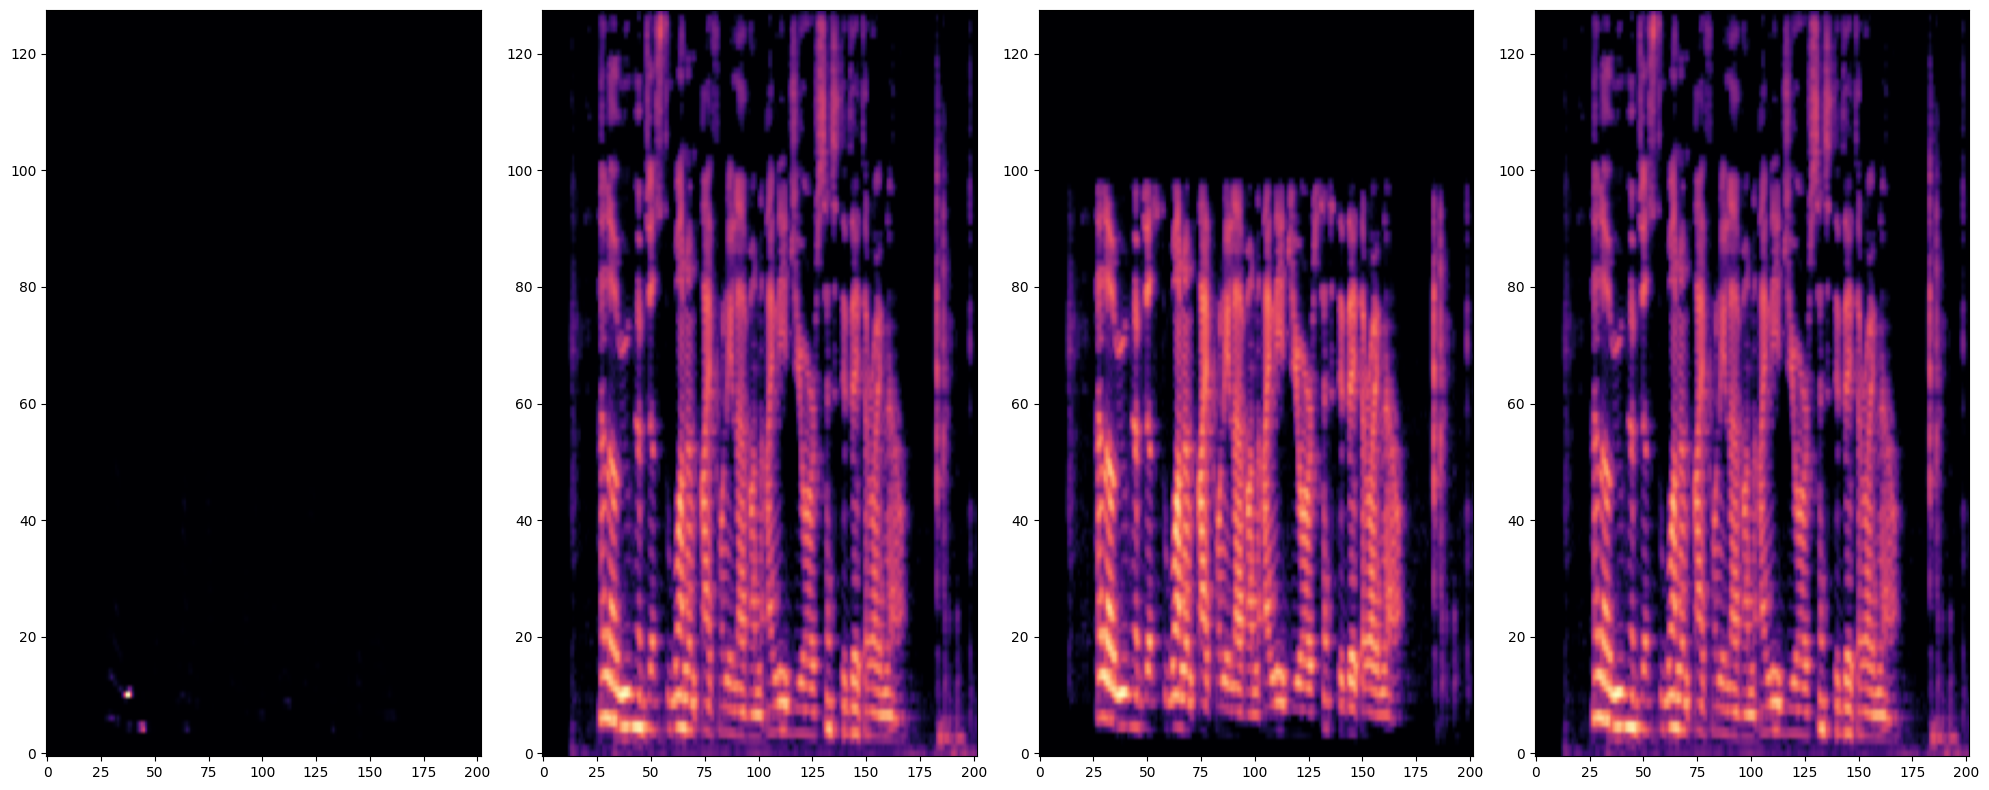

In [ ]:
#Plot different spectrograms to see the transformation from linear scale to logarithmic and see the effect of simulate_telephone

fig, axes = plt.subplots(1, 4, figsize=(20, 8))
axes = axes.flatten()
audio, _ = librosa.load("/content/drive/MyDrive/MaliciousCallDetection/records/malicious_2.wav", sr=16000)
mel_spec = librosa.feature.melspectrogram(y=audio, sr=16000, n_fft=2048,hop_length=512, n_mels=128) #shape=(128,157)
axes[0].imshow( #raw spectrogram
    mel_spec,
    origin='lower',
    aspect='auto',
    cmap='magma'
)


log_mel = librosa.power_to_db(mel_spec, ref=np.max) #ref=np.max means that the loudest point will be 0dB
axes[1].imshow( #logarithmc form
    log_mel,
    origin='lower',
    aspect='auto',
    cmap='magma'
)

telephone=simulate_telephone(audio,sr=16000,prob=1)
telephone_mel_spec = librosa.feature.melspectrogram(y=telephone, sr=16000, n_fft=2048,hop_length=512, n_mels=128)
telephone_log_mel = librosa.power_to_db(telephone_mel_spec, ref=np.max)
axes[2].imshow( #with noise
    telephone_log_mel,
    origin='lower',
    aspect='auto',
    cmap='magma'
)

log_mel = np.clip(log_mel, -80, 0)
log_mel = (log_mel - np.mean(log_mel)) / (np.std(log_mel) + 1e-9)
axes[3].imshow( #standardization
    log_mel,
    origin='lower',
    aspect='auto',
    cmap='magma'
)
plt.tight_layout()
plt.show()

In [4]:
%cd /content/drive/MyDrive/MaliciousCallDetection
!git add
!git pull --rebase

/content/drive/MyDrive/MaliciousCallDetection
error: cannot pull with rebase: You have unstaged changes.
error: please commit or stash them.


In [3]:
!git push

/content/drive/MyDrive/MaliciousCallDetection
Auto packing the repository in background for optimum performance.
See "git help gc" for manual housekeeping.
[main 5b407c1] Added RFP Audio_With_Noise and generated normal spectrograms + ran model 22


In [3]:
%cd /content/drive/MyDrive/MaliciousCallDetection/dataset/validation/Audio_With_Noise
!ls -1 | grep "RFP" |wc -l

/content/drive/MyDrive/MaliciousCallDetection/dataset/validation/Audio_With_Noise
991


Model version: 22


Normal data=54691, Malicious=37570
Weights applied: Normal=0.84, Malicious=1.23
Starting training on cuda...


Epoch [1/30] | Loss Train: 0.3783 | Loss Validation: 0.3244 | Accuracy: 93.84%
Validation Loss droped. We saved the current model.


Epoch [2/30] | Loss Train: 0.3047 | Loss Validation: 0.2967 | Accuracy: 94.70%
Validation Loss droped. We saved the current model.


Epoch [3/30] | Loss Train: 0.2835 | Loss Validation: 0.2952 | Accuracy: 95.04%
Validation Loss droped. We saved the current model.


...

Epoch [26/30] | Loss Train: 0.2198 | Loss Validation: 0.2714 | Accuracy: 96.11%


Epoch [27/30] | Loss Train: 0.2193 | Loss Validation: 0.2717 | Accuracy: 96.11%


Epoch [28/30] | Loss Train: 0.2186 | Loss Validation: 0.2714 | Accuracy: 96.02%


Epoch [29/30] | Loss Train: 0.2183 | Loss Validation: 0.2701 | Accuracy: 96.10%


Epoch [30/30] | Loss Train: 0.2186 | Loss Validation: 0.2685 | Accuracy: 96.15%
Done training. Best model saved as: /content/drive/MyDrive/MaliciousCallDetection/models/malicious_call_detector_v22_best.pt
Load the model from: /content/drive/MyDrive/MaliciousCallDetection/models/malicious_call_detector_v22_best.pt...
Calculating optimal decision threshold using Validation Set

Optimal Threshold Found: 0.6179


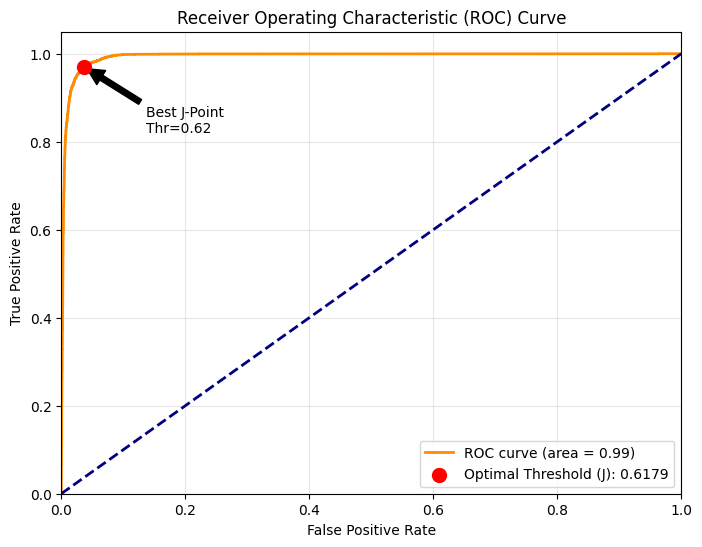

Start testing...

 36 (False Negatives):
 - 269242_normalized_spectogram_11.pt
 - fraud_call114_spectogram_0.pt
 - fraud_call115_spectogram_1.pt
 - fraud_call154_spectogram_5.pt
 - fraud_call154_spectogram_1.pt
 - RFP_PF_14227_spectogram_1.pt
 - fraud_call114_spectogram_1.pt
 - Installing 100 Viruses - Calling Tech Support Scammers [WKLRKCVar6Y]_spectogram_1.pt
 - 27775_normalized_spectogram_4.pt
 - RFP_PF_30730_spectogram_2.pt
Accuracy: 97.20%
Precision: 0.9467 How many relevant samples did we get
Recall: 0.9912 How many malicious did we get right
F1-Score: 0.9684 Final Grade


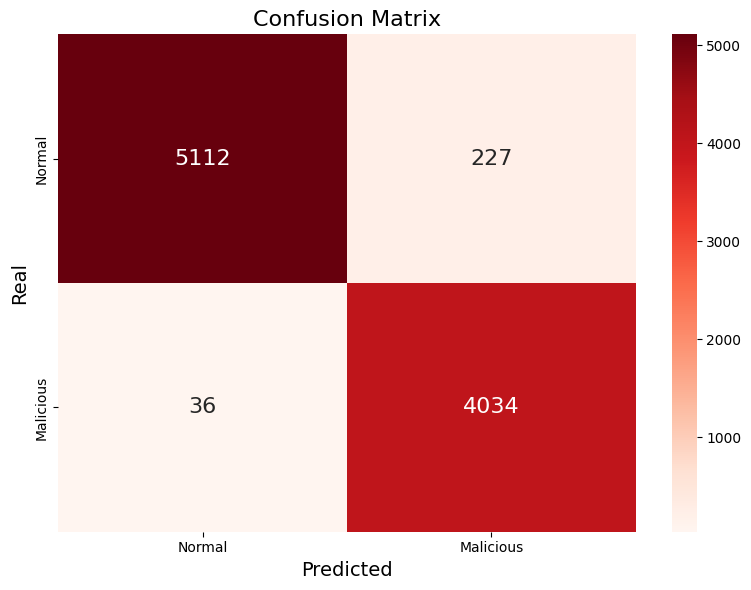

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
lr,█▇▇▆▅▃▂▂▁▁███▇▇▇▆▆▅▅▄▃▃▂▂▂▁▁▁▁
train/accuracy,▁▄▅▆▆▇▇▇▇▇▆▇▇▇▇▇▇▇████████████
train/loss,█▅▄▃▃▂▂▂▂▂▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
val/accuracy,▁▃▄▃▆▅▇▇█▇▅▆▇▇▅█▆▅█▆████▇██▇██
val/loss,█▅▄▆▃▅▃▂▂▂▄▃▂▃▄▂▃▃▂▃▁▁▂▁▂▁▁▁▁▁
epoch,30
lr,0.0
test/accuracy,97.2048
test/f1,0.96843
test/precision,0.94673


In [ ]:
def main(model_version: int,
         lr: float=3e-4,
         epochs: int=30, #2 full cycles
         batch_size: int=32):
  data_path='/content/spectrograms'


  train_model(
        path=data_path,
        model_no=model_version,
        lr=lr,
        epochs=epochs,
        bs=batch_size
    )
if __name__ == "__main__":
  model_version=0
  model_path="/content/drive/MyDrive/MaliciousCallDetection/models"
  for f in os.listdir(model_path):
    if model_version < int(f.split("_v")[1].split("_best")[0]):
      model_version = int(f.split("_v")[1].split("_best")[0])
  model_version+=1
  print(f"Model version: {model_version}")
  main(model_version=model_version)


In [ ]:

def evaluate_best_model(model_path: str,
                        val_loader:torch.utils.data.DataLoader,
                        test_loader: torch.utils.data.DataLoader,
                        device: torch.device,
                        run: Optional[wandb.sdk.wandb_run.Run]):

  if not os.path.exists(model_path):
    print(f"ERORRE: Nu am găsit niciun model la calea: {model_path}")
    return

  print(f"Load the model from: {model_path}...")

  misclassified_malicious=[]

  if 'v9' in model_path:
    model=ResNet18()
  else:
    model = CNN()
  model.load_state_dict(torch.load(model_path, map_location=device))
  model.to(device)
  model.eval()

  print("Calculating optimal decision threshold using Validation Set\n")

  val_probs=[]
  val_labels=[]

  with torch.no_grad():
    for X_val, y_val,_ in val_loader:
      X_val, y_val = X_val.to(device), y_val.to(device)
      pred=model(X_val)

      probs=torch.softmax(pred,dim=1)[:,1] #take column 1 (probablity of malicious)
      val_probs.extend(probs.cpu().numpy())
      val_labels.extend(y_val.cpu().numpy())

  fpr, tpr, thresholds = roc_curve(val_labels, val_probs)
  j_scores = tpr - fpr
  best_idx = np.argmax(j_scores)
  best_threshold = thresholds[best_idx]
  print(f"Optimal Threshold Found: {best_threshold:.4f}")

  # AUC (Area Under Curve) - it should be as close to 1 as possible
  roc_auc = auc(fpr, tpr)
  plt.figure(figsize=(8, 6))

  plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')

  plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

  plt.scatter(fpr[best_idx], tpr[best_idx], color='red', s=100,
              label=f'Optimal Threshold (J): {best_threshold:.4f}', zorder=5)

  plt.xlim([0.0, 1.0])
  plt.ylim([0.0, 1.05])
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title('Receiver Operating Characteristic (ROC) Curve')
  plt.legend(loc="lower right")
  plt.grid(alpha=0.3)

  plt.annotate(f'Best J-Point\nThr={best_threshold:.2f}',
              xy=(fpr[best_idx], tpr[best_idx]),
              xytext=(fpr[best_idx]+0.1, tpr[best_idx]-0.15),
              arrowprops=dict(facecolor='black', shrink=0.05))

  plt.show()
  checkpoint = {
    'model_state_dict': model.state_dict(),
    'threshold': float(best_threshold),
    'model_version': 'CNN_v2',
    }

  torch.save(checkpoint, model_path)


  test_preds = []
  test_labels = []

  print("Start testing...")

  with torch.no_grad():
    for X_test, y_test,paths in test_loader:
      X_test = X_test.to(device)
      y_test = y_test.to(device)

      pred = model(X_test)
      probs = torch.softmax(pred, dim=1)[:, 1] #prob of malicious

      predicted = (probs >= best_threshold).long()

      for i in range(len(y_test)):
        if y_test[i] == 1 and predicted[i] == 0:
          file_name = os.path.basename(paths[i])
          misclassified_malicious.append(file_name)

      # GPU->CPU for Scikit-Learn
      test_preds.extend(predicted.cpu().numpy())
      test_labels.extend(y_test.cpu().numpy())

  accuracy = np.mean(np.array(test_preds) == np.array(test_labels)) * 100
  precision = precision_score(test_labels, test_preds, zero_division=0) #How many relevant samples did we get  tp/(tp+fp)
  recall = recall_score(test_labels, test_preds, zero_division=0) #How many malicious did we get right tp/(tp+fn)
  f1 = f1_score(test_labels, test_preds, zero_division=0) #Final grade  2*p*r/(p+r) harmonic mean
  if run:
    run.summary["test/accuracy"] = accuracy
    run.summary["test/precision"] = precision
    run.summary["test/recall"] = recall
    run.summary["test/f1"] = f1

    run.log({"test/confusion_matrix": wandb.plot.confusion_matrix(
            probs=None,
            y_true=test_labels,
            preds=test_preds,
            class_names=['Normal', 'Malicious']
        )})
    print(f"\n {len(misclassified_malicious)} (False Negatives):")
    for name in misclassified_malicious[:10]:
        print(f" - {name}")

    my_table = wandb.Table(columns=["File Name", "Status"])
    for name in misclassified_malicious:
        my_table.add_data(name, "False Negative")
    run.log({"misclassified_files": my_table})

  print(f"Accuracy: {accuracy:.2f}%")
  print(f"Precision: {precision:.4f} How many relevant samples did we get")
  print(f"Recall: {recall:.4f} How many malicious did we get right")
  print(f"F1-Score: {f1:.4f} Final Grade")

  # Confusion Matrix
  cm = confusion_matrix(test_labels, test_preds)

  plt.figure(figsize=(8, 6))
  sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
              xticklabels=['Normal', 'Malicious'],
              yticklabels=['Normal', 'Malicious'],
              annot_kws={"size": 16})

  plt.ylabel('Real', fontsize=14)
  plt.xlabel('Predicted', fontsize=14)
  plt.title('Confusion Matrix', fontsize=16)
  plt.tight_layout()
  plt.show()

In [ ]:
from sklearn.metrics import precision_recall_curve,roc_curve,auc

def train_model(path: str,
                model_no: int,
                lr: float,
                epochs: int,
                bs: int):

  model = CNN()
  device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
  model = model.to(device)
  if device.type=="cpu" :
    print("ERROR! Not using GPU")
    return

  train_files,val_files,test_files=spectrograms_random_splits(path)

  count_normal=len([f for f in train_files if f[1]==0])
  count_mal=len([f for f in train_files if f[1]==1])

  total_train = count_normal + count_mal
  w_normal = total_train / (2 * count_normal)
  w_malicious = total_train / (2 * count_mal)

  run=wandb.init(entity="dragosmarinescu19-babes-bolyai-university",
              name=f"run{model_no}",
              project="MaliciousCallDetection",
              config={
                  "lr":lr,
                  "batch_size":bs,
                  "epochs":epochs,
                  "label_smoothing":0.1,
                  "SpecAugment":True,
                  "normal_weights":w_normal,
                  "malicious_weights":w_malicious,
                  "optimizer":"AdamW",
                  "model_architecture": "CNN"
               })

  class_weights = torch.tensor([w_normal, w_malicious], dtype=torch.float).to(device)
  print(f"Normal data={count_normal}, Malicious={count_mal}")
  print(f"Weights applied: Normal={w_normal:.2f}, Malicious={w_malicious:.2f}")

  loss_func = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=run.config.label_smoothing)
  optimizer = configure_optimizer(model,run.config.lr)

  #Modified from ReduceLROnPlateau
  scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
      optimizer, T_0=10, T_mult=2, eta_min=1e-6) #changed from 5 to 10
  #after 5 epochs lr= maximum, then doubles the nr of epochs, the lr is continuously going down to min

  train_db=Spectrogram(train_files,augment=True)
  val_db=Spectrogram(val_files,augment=False)
  test_db=Spectrogram(test_files,augment=False)

  # traind_db =[1,128,157]
  # after DataLoader train_loader=[32,1,128,157] 32 bathces, 1 channel, height, width
  train_loader = DataLoader(train_db, batch_size=run.config.batch_size, shuffle=True,num_workers=2,pin_memory=True,persistent_workers=True)
  val_loader = DataLoader(val_db, batch_size=run.config.batch_size, shuffle=False,num_workers=2,pin_memory=True,persistent_workers=True)
  test_loader = DataLoader(test_db, batch_size=run.config.batch_size, shuffle=False,num_workers=2,pin_memory=True)
  epochs = run.config.epochs

  best_val_loss = float('inf') # We look after the best score
  best_model_path = f'/content/drive/MyDrive/MaliciousCallDetection/models/malicious_call_detector_v{model_no}_best.pt'

  print(f"Starting training on {device}...")

  for epoch in range(epochs):
    model.train() # Put model in training mode
    train_loss = 0.0
    train_correct=0
    train_total=0

    total_batches=len(train_loader) #total spectrograms / batch size
    batch_loop=tqdm(train_loader, desc=f"Epoch [{epoch+1}/{epochs}]", leave=False)

    for i, (X_train, y_train,_) in enumerate(batch_loop):
      # Move data to the same device as the model
      X_train = X_train.to(device)
      y_train = y_train.to(device)

      optimizer.zero_grad()
      pred = model(X_train)
      loss = loss_func(pred, y_train)
      loss.backward() #calculate how to fix the error
      optimizer.step() #update the weights

      scheduler.step(epoch + i / total_batches)

      train_loss += loss.item()*X_train.size(0)

      #compare the prediction vector to the y_train vector wich contains labels, then we'll have a boolean tensor
      #after the sum we'll have the number of True elements inside a scalar tensor
      #then we use item() to get the number as a python int
      train_correct+=(pred.argmax(dim=1)==y_train).sum().item()
      train_total+=y_train.size(0)

      current_acc=100 * train_correct / train_total
      current_lr=optimizer.param_groups[0]['lr']
      batch_loop.set_postfix(loss=loss.item(), acc=f"{current_acc:.2f}%", lr=f"{current_lr:.2e}")

    train_acc=train_correct/train_total
    avg_train_loss=train_loss/len(train_loader.dataset)

    # VALIDATION

    model.eval() # STOP the dropout
    val_loss = 0.0
    val_correct=0
    val_total=0

    with torch.no_grad():
      for X_val, y_val,_ in val_loader:
        X_val, y_val = X_val.to(device), y_val.to(device)

        pred = model(X_val)
        loss = loss_func(pred, y_val)
        val_loss += loss.item() * X_val.size(0)

        # Accuracy
        val_correct += (pred.argmax(dim=1) == y_val).sum().item()
        val_total+=y_val.size(0)

    avg_val_loss = val_loss / len(val_loader.dataset)
    current_lr = optimizer.param_groups[0]['lr']

    val_acc = val_correct/val_total
    run.log({"train/loss":avg_train_loss,
             "train/accuracy":train_acc,
             "val/loss":avg_val_loss,
             "val/accuracy":val_acc,
             "lr":current_lr,
             "epoch":epoch+1
             })

    print(f"Epoch [{epoch+1}/{epochs}] | Loss Train: {avg_train_loss:.4f} | Loss Validation: {avg_val_loss:.4f} | Accuracy: {val_acc*100:.2f}%")

    #SAVE
    if avg_val_loss < best_val_loss:
      best_val_loss = avg_val_loss
      torch.save(model.state_dict(), best_model_path)
      print(f"Validation Loss droped. We saved the current model.")

  print(f"Done training. Best model saved as: {best_model_path}")

  evaluate_best_model(best_model_path, val_loader,test_loader, device,run)

  run.finish()


In [ ]:
import math

def predict_audio(model_path,file_path,device,model=None,threshold=0.5,sr=16000, n_mels=128,window_size=5.0,min_overlap=1.5,plot=False):
  if model is None:
    model_number = int(model_path.split("_v")[1].split("_best")[0])
    if model_number<6:
      model=OldCNN()
      print("Predicting using OldCNN")
    else:
      if model_number==9:
        model = ResNet18()
        print("Predicting using ResNet18")
      else:
        model = CNN()
        print("Predicting using CNN")

    checkpoint=torch.load(model_path, map_location=device)

    if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
        threshold = checkpoint.get('threshold', 0.5)
    else:
        model.load_state_dict(checkpoint) # fallback (V6 or lower)
        threshold = 0.5 # fallback threshold

    print(f"Running model {model_number} with threshold {threshold} \n")

    model.to(device)
    model.eval()


  #START CREATING SPECTROGRAMS
  window_size_samples = int(window_size * sr)
  min_overlap_samples = int(min_overlap * sr)

  try:
    audio, _ = librosa.load(file_path, sr=sr)
    total_samples=len(audio)
    if(total_samples<2.5*sr):
      print("Audio too short for a reliable prediction")
      return
    if(total_samples>6000*sr):
      print("Audio is too long, shorten the audio file and try again")
      return
  except Exception as e:
    print(f"Error loading {file_path}: {e}")

  if total_samples < int(8.5 * sr) and total_samples >= window_size_samples:
    step = max(1, total_samples - window_size_samples)
  else:
    step = window_size_samples - min_overlap_samples
  spectrograms=[]

  for start in range(0, total_samples, step):
    audio_segment = audio[start : min(total_samples,start + window_size_samples)]

    if len(audio_segment) < window_size_samples:
      pad_length = window_size_samples - len(audio_segment)
      audio_segment = np.pad(audio_segment, (0, pad_length), mode="constant")

    if is_silent(audio_segment, sr): #skip window
      continue

    mel_spec = librosa.feature.melspectrogram(y=audio_segment, sr=sr, n_fft=2048,hop_length=512, n_mels=128) #shape=(128,157)

    log_mel = librosa.power_to_db(mel_spec, ref=np.max) #ref=np.max means that the loudest point will be 0dB
    log_mel = np.clip(log_mel, -80, 0)
    log_mel = (log_mel - np.mean(log_mel)) / (np.std(log_mel) + 1e-9)

    tensor_mel = torch.tensor(log_mel,dtype=torch.float32).unsqueeze(0).unsqueeze(0) # shape: [1, 1, n_mels, time]
    spectrograms.append(tensor_mel)

  #DONE CREATING SPECTROGRAMS
  fix,axes=None,None
  if plot:
    fig, axes = plt.subplots(math.ceil(len(spectrograms)/5), 5, figsize=(20,8))
    axes=axes.flatten()

  malicious_windows_count=0
  with torch.no_grad():
    total_probs=[]
    for idx,x in enumerate(spectrograms):
      x=x.to(device)
      pred = model(x)
      prob=torch.softmax(pred,dim=1) #tensor([[0.31, 0.69]])

      malicious_prob=prob[0][1].item()
      is_malicious=malicious_prob>=threshold
      if is_malicious:
        malicious_windows_count+=1

      total_probs.append(prob.cpu().numpy()[0]) # array([0.31, 0.69], dtype=float32)


      if plot:
        mel = x.squeeze(0).squeeze(0).cpu().numpy()# (128,157)
        axes[idx].imshow(
            mel,
            origin='lower',
            aspect='auto',
            cmap='magma'
        )

        axes[idx].set_title(f"Malicious ({malicious_prob:.2f})" if is_malicious else f"Normal ({1 - malicious_prob:.2f})")
        axes[idx].set_xlabel("Time")
        axes[idx].set_ylabel("Mel bins")

    if plot:
      plt.tight_layout()
      plt.show()
      plt.close(fig)

  malicious_ratio=malicious_windows_count/len(spectrograms)
  predicted_class = 1 if malicious_ratio >= 0.5 else 0

  avg_probs=np.mean(total_probs,axis=0)
  confidence=avg_probs[predicted_class]*100
  if plot:
    print(f"Threshold Used: {threshold:.4f}")
    print(f"Malicious Windows: {malicious_windows_count}/{len(spectrograms)} ({malicious_ratio*100:.1f}%)")
    print("Predicted class: Malicious") if predicted_class==1 else print("Predicted class: Normal")
    print(f"Confidence: {confidence:.2f}")
  return predicted_class


In [ ]:
#import sounddevice as sd for audio recording
from scipy.io.wavfile import write
import os
import librosa
import torch
import numpy as np
import torch
from sklearn.metrics import confusion_matrix, classification_report
from IPython.display import Audio
from tqdm import tqdm

def run_predictions(validation_path,device,model_path):

  y_true = []
  y_pred = []
  model_number = int(model_path.split("_v")[1].split("_best")[0])
  if model_number<6:
    model=OldCNN()
  else:
    if model_number==9:
      model = ResNet18()
    else:
      model = CNN()
  checkpoint=torch.load(model_path, map_location=device)

  if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
      model.load_state_dict(checkpoint['model_state_dict'])
      threshold = checkpoint.get('threshold', 0.5)
  else:
      model.load_state_dict(checkpoint) # fallback (V6 or lower)
      threshold = 0.5 # fallback threshold

  print(f"Running model {model_number} with threshold {threshold} \n")

  model.to(device)
  model.eval()

  for category in os.listdir(validation_path):
    if category not in ["normal","malicious"]:continue
    print(f"Processing category {category}...\n")
    dir_path=os.path.join(validation_path,category)
    if not os.path.exists(dir_path):
      continue
    valid_files = [f for f in os.listdir(dir_path) if f.lower().endswith(('.wav', '.mp3'))]
    label = 0 if category == 'normal' else 1

    for f in tqdm(valid_files, desc=f"{category} progress", unit="file"):
      full_path = os.path.join(dir_path, f)
      predicted=predict_audio(model_path,full_path,device,model,threshold)
      if predicted is not None:
        y_true.append(label)
        y_pred.append(predicted)

  print(classification_report(y_true, y_pred, target_names=['Normal', 'Malicious']))

  cm = confusion_matrix(y_true, y_pred)

  plt.figure(figsize=(8, 6))
  sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
              xticklabels=['Normal', 'Malicious'],
              yticklabels=['Normal', 'Malicious'],
              annot_kws={"size": 16})

  plt.ylabel('Real', fontsize=14)
  plt.xlabel('Predicted', fontsize=14)
  plt.title('Confusion Matrix', fontsize=16)
  plt.tight_layout()
  plt.show()


Running model 22 with threshold 0.617917001247406 

Processing category normal...



normal progress: 100%|██████████| 1050/1050 [01:54<00:00,  9.17file/s]


Processing category malicious...



malicious progress: 100%|██████████| 7608/7608 [10:58<00:00, 11.56file/s]


              precision    recall  f1-score   support

      Normal       0.99      0.97      0.98      1050
   Malicious       1.00      1.00      1.00      7608

    accuracy                           0.99      8658
   macro avg       0.99      0.98      0.99      8658
weighted avg       0.99      0.99      0.99      8658



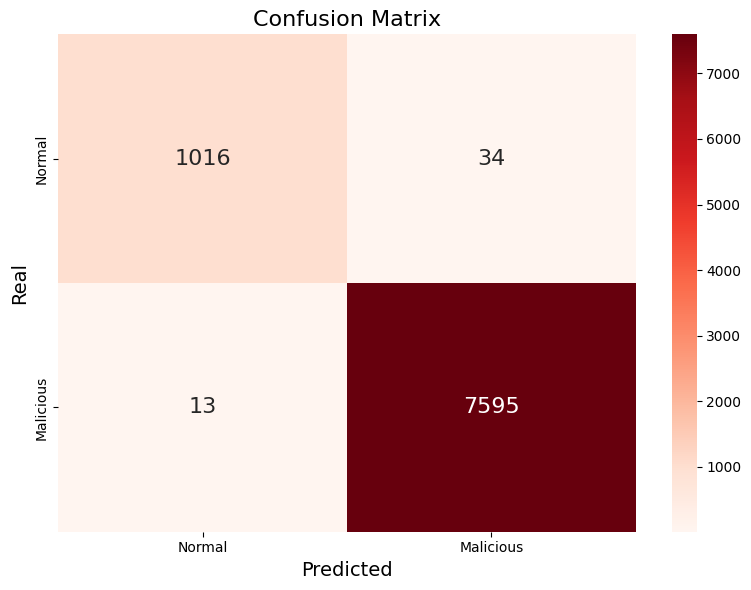

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_path="/content/drive/MyDrive/MaliciousCallDetection/models/malicious_call_detector_v22_best.pt"
base_path="/content/drive/MyDrive/MaliciousCallDetection/dataset/validation"
def evaluate_category(device,model_path,base_path):
  all_predict=0
  category="PF_malicious"
  dir_path=os.path.join(base_path,category)
  if not os.path.exists(dir_path):
    return
  valid_files = [f for f in os.listdir(dir_path) if f.lower().endswith(('.wav', '.mp3'))]
  idx=1
  for f in valid_files:
    full_path = os.path.join(dir_path, f)
    predicted=predict_audio(model_path,full_path,"cuda",plot=False)
    all_predict+=predicted
  print(f"Malicious calls caught {all_predict}/{131}") #0/131 la v8 si 129/131 la v14 si 72/131 la v15, ... la v17`

#evaluate_category(device,model_path,base_path)
run_predictions(base_path,device,model_path)
#predict_audio(model_path,"/content/drive/MyDrive/MaliciousCallDetection/records/Sales Call example 1 [4ostqJD3Psc].wav",device="cuda",plot=True)

In [ ]:
from pydub import AudioSegment
def get_minutes_from_audio(path):
  for category in ["normal","malicious"]:
    dir_path=os.path.join(path,category)
    if not os.path.exists(dir_path):
      print(f"The specified path doesn't exist {dir_path} ... \n")
      continue
    valid_files = [f for f in os.listdir(dir_path) if f.lower().endswith(('.wav', '.mp3'))]
    total_seconds=0
    for f in valid_files:
      full_path=os.path.join(dir_path,f)
      try:
        audio=AudioSegment.from_file(full_path)
        total_seconds+=len(audio)/1000.0
      except Exception as e:
        print(f"Error loading {full_path}: {e}")

    print(total_seconds)
    print(f"Minutes of audio in {category} ",total_seconds/60,"\n")

#get_minutes_from_audio("/content/drive/MyDrive/MaliciousCallDetection/dataset")

#57 minutes of audio in validation/normal
#1046 minutes of audio in valdiation/malicious

#1545 minutes of audio in dataset/normal
#1900 minutes of audio in dataset/malicious

In [ ]:
import optuna
from optuna.visualization import plot_optimization_history, plot_param_importances

train_files, val_files, _ = spectrograms_random_splits("/content/spectrograms")
train_db = Spectrogram(train_files, augment=True)
val_db = Spectrogram(val_files, augment=False)

def objective(trial):
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True) # Learning rates should always be searched logarithmically
    weight_decay = trial.suggest_float("weight_decay", 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])
    conv_dropout = trial.suggest_float("conv_dropout", 0.1,0.4)
    dropout = trial.suggest_float("dropout", 0.3, 0.6)
    label_smoothing = trial.suggest_float("label_smoothing", 0.02, 0.15) #because the model was to confident
    T_0 = trial.suggest_categorical("T_0", [5, 10])

    device = torch.device("cuda")
    model = CNN(conv_dropout=conv_dropout,dropout=dropout).to(device)


    train_loader = DataLoader(train_db, batch_size=batch_size, shuffle=True,num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_db, batch_size=batch_size, shuffle=False,num_workers=2, pin_memory=True)

    count_normal = len([f for f in train_files if f[1] == 0])
    count_mal = len([f for f in train_files if f[1] == 1])
    total_train = count_normal + count_mal
    w_normal = total_train / (2 * count_normal)
    w_malicious = total_train / (2 * count_mal)
    class_weights = torch.tensor([w_normal, w_malicious], dtype=torch.float).to(device)

    loss_func = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=label_smoothing)
    optimizer = optim.AdamW(model.parameters(), lr=lr,weight_decay=weight_decay) # AdamW instead of Adam
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=T_0, T_mult=2, eta_min=1e-6)

    n_epochs = 25
    best_val_loss = float('inf')

    for epoch in range(n_epochs):
        model.train()
        total_batches = len(train_loader)
        batch_loop=tqdm(train_loader, desc=f"Epoch [{epoch+1}/{n_epochs}]", leave=False)

        for i, (X, y, _) in enumerate(batch_loop):
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            pred = model(X)
            loss = loss_func(pred, y)
            loss.backward()
            optimizer.step()
            scheduler.step(epoch + i / total_batches)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X, y, _ in val_loader:
                X, y = X.to(device), y.to(device)
                pred = model(X)
                loss = loss_func(pred, y)
                val_loss += loss.item() * X.size(0)

        avg_val_loss = val_loss / len(val_loader.dataset)
        best_val_loss = min(best_val_loss, avg_val_loss)

        # Optuna pruning: stop bad trials early
        trial.report(avg_val_loss, epoch)
        if trial.should_prune(): #if loss is really bad compared to other trials then it kills the loop
            raise optuna.exceptions.TrialPruned()

    return best_val_loss
# Run the study
study = optuna.create_study(
    study_name="CNN_Hyperparameter_Tuning_v19",
    direction="minimize",
    pruner=optuna.pruners.MedianPruner(n_startup_trials=3, n_warmup_steps=5)
)
study.optimize(objective, n_trials=50, timeout=36000)  # 50 trials or 10h max
print("Best trial:")
print(f"  Val Loss: {study.best_trial.value:.4f}")
print(f"  Params: {study.best_trial.params}")
plot_optimization_history(study).show()
plot_param_importances(study).show()  #shows how important si the change in different parameters

In [ ]:
from google.colab import runtime
runtime.unassign()

In [ ]:
from sklearn.model_selection import KFold

def kfold(spectogram_path, n_folds=5):
  normal_sources = {}
  malicious_sources = {}

  for label, category in enumerate(['normal', 'malicious']):
      dir_path = os.path.join(spectogram_path, category)
      if not os.path.exists(dir_path): continue
      for f in os.listdir(dir_path):
          if f.endswith('.pt'):
              source_name = f"{category}_{f.split('_spectogram_')[0]}"
              full_path = os.path.join(dir_path, f)
              target = normal_sources if label == 0 else malicious_sources
              if source_name not in target:
                  target[source_name] = {'samples': [], 'label': label}
              target[source_name]['samples'].append(full_path)

  def get_folds(source_dict):
      source_ids = sorted(source_dict.keys())
      kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)
      return [(
          [source_ids[i] for i in train_idx],
          [source_ids[i] for i in val_idx]
      ) for train_idx, val_idx in kf.split(source_ids)]

  norm_folds = get_folds(normal_sources)
  mal_folds = get_folds(malicious_sources)

  def flatten(ids_list, source_dict):
    flat = []
    for sid in ids_list:
      for sample in source_dict[sid]['samples']:
        flat.append((sample, source_dict[sid]['label']))
    return flat

  all_folds = []
  for i in range(n_folds):
    train = (flatten(norm_folds[i][0], normal_sources) +
              flatten(mal_folds[i][0], malicious_sources))
    val = (flatten(norm_folds[i][1], normal_sources) +
            flatten(mal_folds[i][1], malicious_sources))
    random.shuffle(train)
    random.shuffle(val)
    all_folds.append((train, val))

  return all_folds


In [ ]:
def main_kfold_evaluation(data_path="/content/spectrograms", n_folds=5):
    folds = kfold(data_path, n_folds=n_folds)

    config = {
        "n_folds": n_folds,
        "epochs": 35,
        "batch_size": 64,
        "lr": 7.197e-05,
        "model_type": "CNN",
        "label_smoothing": 0.00006
    }
    group_id = f"kfold-session-{wandb.util.generate_id()}"
    rezultate_folduri = []

    for fold_idx, (train_files, val_files) in enumerate(folds):
        run = wandb.init(
            project="MaliciousCallDetection",
            group=group_id,
            name=f"fold_{fold_idx + 1}",
            config=config,
            reinit=True # Allows multiple runs in one script
        )
        print(f"{fold_idx + 1} / {n_folds}")

        train_db = Spectrogram(train_files, augment=True)
        val_db = Spectrogram(val_files, augment=False)

        train_loader = DataLoader(train_db, batch_size=64, shuffle=True,num_workers=2,pin_memory=True)
        val_loader = DataLoader(val_db, batch_size=64, shuffle=False,num_workers=2,pin_memory=True)

        device = torch.device("cuda")
        model = CNN().to(device)
        count_normal=len([f for f in train_files if f[1]==0])
        count_mal=len([f for f in train_files if f[1]==1])

        total_train = count_normal + count_mal
        w_normal = total_train / (2 * count_normal)
        w_malicious = total_train / (2 * count_mal)

        class_weights = torch.tensor([w_normal, w_malicious], dtype=torch.float).to(device)

        loss_func = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.00006) #added label_smoothing
        optimizer = configure_optimizer(model,lr=7.197539212437107e-05)

        scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
            optimizer, T_0=5, T_mult=2, eta_min=1e-6)
        epochs=35
        best_f1_fold=0.0
        for epoch in range(epochs):
          model.train()
          train_loss = 0.0
          train_correct = 0
          train_total = 0

          total_batches = len(train_loader)
          batch_loop = tqdm(train_loader, desc=f"Fold {fold_idx+1} | Epoch [{epoch+1}/{epochs}]", leave=False)

          for i, (X_train, y_train,_) in enumerate(batch_loop):
            X_train = X_train.to(device)
            y_train = y_train.to(device)

            optimizer.zero_grad()
            pred = model(X_train)
            loss = loss_func(pred, y_train)
            loss.backward()
            optimizer.step()

            scheduler.step(epoch + i / total_batches)

            train_loss += loss.item()*X_train.size(0)
            train_correct+=(pred.argmax(dim=1)==y_train).sum().item()
            train_total+=y_train.size(0)

            current_acc=100 * train_correct / train_total
            current_lr=optimizer.param_groups[0]['lr']
            batch_loop.set_postfix(loss=loss.item(), acc=f"{current_acc:.2f}%", lr=f"{current_lr:.2e}")

          train_acc=train_correct/train_total
          avg_train_loss=train_loss/len(train_loader.dataset)

          # VALIDATION

          model.eval() # STOP the dropout
          val_loss = 0.0
          val_probs = []
          val_labels = []

          with torch.no_grad():
            for X_val, y_val,_ in val_loader:
              X_val, y_val = X_val.to(device), y_val.to(device)

              pred = model(X_val)
              loss = loss_func(pred, y_val)
              val_loss += loss.item() * X_val.size(0)

              probs = torch.softmax(pred, dim=1)[:, 1]
              val_probs.extend(probs.cpu().numpy())
              val_labels.extend(y_val.cpu().numpy())

          precisions, recalls, thresholds = precision_recall_curve(val_labels, val_probs)
          f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
          current_val_f1 = np.max(f1_scores)
          avg_val_loss = val_loss / len(val_loader.dataset)

          print(f"Val_Loss: {avg_val_loss:.4f} | Val_Max_F1: {current_val_f1:.4f}")
          if current_val_f1 > best_f1_fold:
              best_f1_fold = current_val_f1
          wandb.log({
                "train/loss": avg_train_loss,
                "train/acc": train_acc,
                "val/loss": avg_val_loss,
                "val/f1_max": current_val_f1,
                "learning_rate": optimizer.param_groups[0]['lr']
            })

        print(f"Fold {fold_idx+1} done. Best F1: {best_f1_fold:.4f}\n")

        run.summary["best_f1"] = best_f1_fold
        run.finish()

        rezultate_folduri.append(best_f1_fold)
    media_f1 = np.mean(rezultate_folduri) * 100
    std_f1 = np.std(rezultate_folduri) * 100

    final_run = wandb.init(project="MaliciousCallDetection", group=group_id, name="final_summary")
    final_run.log({"kfold_avg_f1": media_f1, "kfold_std_f1": std_f1})
    final_run.finish()
    print(f"F1-Score Mean: {media_f1:.2f}% ± {std_f1:.2f}%")
main_kfold_evaluation()

In [ ]:
import os
from google.colab import files


zip_path = "/content/spectrograms"
output_zip_file = "/content/spectrograms_backup.zip"

!zip -r "{output_zip_file}" "{zip_path}"
print(f"Folder '{zip_path}' zipped to '{output_zip_file}'")

!cp /content/spectrograms_backup.zip /content/drive/MyDrive/MaliciousCallDetection/spectrograms_backup.zip
print(f"Archive copied in Drive")

In [ ]:
#Convolutional Filter and high pass filters to highlight the high freq info in an image
def convolution(X, W, bias, pad, stride):

  num_samples = X.shape[0]
  iW = X.shape[2]
  iH = X.shape[1]
  f = W.shape[0]
  # compute the output width (oW), height (oH) and number of channels (oC)
  oW=(iW - f + 2 * pad)//stride +1
  oH=(iH - f + 2 * pad)//stride +1
  oC=W.shape[1]
  # initialize the output activation map with zeros
  activation_map = np.zeros((num_samples, oH, oW, oC))
  X_padded = zero_pad(X,pad)

  for i in range(num_samples):
    X_i = X_padded[i]

    # loop over the spatial dimensions
    for y in range(oH):

      # tl_y - the y coordinate of the top left corner of the current region
      # br_y - the y coordinate of the bottom right corner of the current region

      tl_y = y * stride
      br_y = tl_y + f

      for x in range(oW):

        tl_x = x * stride
        br_x = tl_x + f
        # end TODO your code here

        for c in range(oC):
            # select the current ROI on which the filter will be applied
            roi = X_i[tl_y: br_y, tl_x: br_x, :]
            w = W[:, c]
            b = bias[:, :, :, c]

            a=np.multiply(roi,w)
            a = np.sum(a)
            a = a + float(b)

            activation_map[i,y,x,c] = a
        assert(activation_map.shape == (num_samples, oH, oW, oC))
  return activation_map



np.random.seed(10)
X=np.random.randn(32,128,157,1)
#X= (batch_size,H,W,C=1)
W = np.random.randn(3, 1)
b = np.random.randn(1, 1, 1, 8)

am = convolution(X, W, b, pad=1, stride=2)
print("am's mean =\n", np.mean(am))
print("am[1, 2, 3] =\n", am[3,2,1])


In [ ]:
sobel_horiz = np.asarray([[-1, 0, 1],
                          [-2, 0, 2],
                          [-1, 0, 1]])

sobel_vert = sobel_horiz.T

sobel_horiz = np.reshape(sobel_horiz, (3, 3, 1, 1))
sobel_vert = np.reshape(sobel_vert, (3, 3, 1, 1))

sobel_x = convolution(X, sobel_horiz, bias, 0, 1)
sobel_y = convolution(X, sobel_vert, bias, 0, 1)


plt.subplot(1, 3, 1)
plt.imshow(image[:, :, 0], cmap='gray')
plt.title('Original image')
plt.subplot(1, 3, 2)
plt.imshow(np.abs(sobel_x[0,:,:,0])/np.abs(np.max(sobel_x[0,:,:,0]))*255, cmap='gray')
plt.title('Sobel X')
plt.subplot(1, 3, 3)
plt.imshow(np.abs(sobel_y[0,:,:,0])/np.abs(np.max(sobel_y[0,:,:,0]))*255, cmap='gray')
plt.title('Sobel Y')
plt.tight_layout()
